# 🔐 Network Intrusion Detection System
## CNN vs RNN vs CNN+LSTM — KDD Train Dataset
### Final Year Project | Deep Learning Models Comparison

---
**What this notebook does:**
1. Loads and prepares the KDD dataset
2. Trains **CNN** model → shows accuracy
3. Trains **RNN** model → shows accuracy  
4. Trains **CNN + LSTM** (combined) model → shows accuracy
5. Compares all 3 models side by side


## Step 1 — Install Required Libraries
Run this cell first. It installs everything needed.

In [4]:
# Run this if you haven't installed these yet
# Click this cell and press Shift+Enter

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "tensorflow", "scikit-learn", "pandas",
                       "matplotlib", "seaborn", "--quiet"])
print("✅ All libraries installed successfully!")


✅ All libraries installed successfully!


## Step 2 — Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils     import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seed so results are same every run
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ NumPy version      : {np.__version__}")
print(f"✅ All imports done!")


✅ TensorFlow version : 2.19.0
✅ NumPy version      : 2.0.2
✅ All imports done!


## Step 3 — Load KDD Dataset

> ⚠️ **Important:** Place your `KDDTrain+.txt` file in the **same folder** as this notebook.
>
> If your file has a different name, change `FILE_PATH` below accordingly.


In [6]:

COLUMN_NAMES = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "attack_type", "difficulty_level"
]


FILE_PATH = "KDDTrain.txt"


df = pd.read_csv(FILE_PATH, header=None, names=COLUMN_NAMES)


df['label'] = df['attack_type'].str.rstrip('.').str.lower()
df = df.drop(['attack_type', 'difficulty_level'], axis=1)


print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n── First 5 rows ──")
print(df.head()) # Use print() for explicit output

✅ Dataset loaded successfully!
   Rows    : 125973
   Columns : 42

── First 5 rows ──
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                  

## Step 4 — See What Attack Types Exist in the Data

In [7]:
print("── All unique labels in dataset ──")
print(df['label'].value_counts())


── All unique labels in dataset ──
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## Step 5 — Prepare / Clean the Data

We do 4 things here:
1. **Map** 40+ attack names → 5 categories (Normal, DoS, Probe, R2L, U2R)
2. **Encode** text columns (like "tcp", "http") into numbers
3. **Scale** all features to same range
4. **Split** into train / validation sets


In [8]:
# ── 5a. Map attacks to 5 categories ─────────────────────────────────────────
#
#   Normal  = normal traffic
#   DoS     = Denial of Service (flood attack)   e.g. neptune, smurf
#   Probe   = Scanning/Probing attack             e.g. nmap, ipsweep
#   R2L     = Remote to Local attack              e.g. guess_passwd
#   U2R     = User to Root attack                 e.g. buffer_overflow

ATTACK_MAP = {
    "normal"          : "Normal",
    # DoS
    "back"            : "DoS",   "land"          : "DoS",
    "neptune"         : "DoS",   "pod"           : "DoS",
    "smurf"           : "DoS",   "teardrop"      : "DoS",
    "apache2"         : "DoS",   "udpstorm"      : "DoS",
    "processtable"    : "DoS",   "worm"          : "DoS",
    "mailbomb"        : "DoS",
    # Probe
    "ipsweep"         : "Probe", "nmap"          : "Probe",
    "portsweep"       : "Probe", "satan"         : "Probe",
    "mscan"           : "Probe", "saint"         : "Probe",
    # R2L
    "ftp_write"       : "R2L",   "guess_passwd"  : "R2L",
    "imap"            : "R2L",   "multihop"      : "R2L",
    "phf"             : "R2L",   "spy"           : "R2L",
    "warezclient"     : "R2L",   "warezmaster"   : "R2L",
    "sendmail"        : "R2L",   "named"         : "R2L",
    "snmpattack"      : "R2L",   "snmpgetattack" : "R2L",
    "xlock"           : "R2L",   "xsnoop"        : "R2L",
    "httptunnel"      : "R2L",
    # U2R
    "buffer_overflow" : "U2R",   "loadmodule"    : "U2R",
    "perl"            : "U2R",   "rootkit"       : "U2R",
    "ps"              : "U2R",   "sqlattack"     : "U2R",
    "xterm"           : "U2R",
}

CLASS_NAMES = ["Normal", "DoS", "Probe", "R2L", "U2R"]
NUM_CLASSES  = 5

# Map the cleaned labels to 5 categories (df['label'] will now contain attack names after c80966108 fix)
df["label"] = df["label"].map(ATTACK_MAP).fillna("DoS")

print("✅ Attack categories mapped!")
print(df["label"].value_counts())

✅ Attack categories mapped!
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [9]:
df["label"] = df["label"].str.lower()   # normalize

label_le = LabelEncoder()
df["label"] = label_le.fit_transform(df["label"])

# ── 4. ENCODE ALL OTHER CATEGORICAL COLUMNS ─────────────────────────────────
for col in df.columns:
    if df[col].dtype == 'object' and col != "label":
        df[col] = LabelEncoder().fit_transform(df[col])

# ── 5. FINAL CHECK ──────────────────────────────────────────────────────────
print("Remaining object columns:", df.select_dtypes(include=['object']).columns)
# Remove leakage columns
if "difficulty_level" in df.columns:
    df = df.drop("difficulty_level", axis=1)

# ── 6. SPLIT FEATURES & LABEL ───────────────────────────────────────────────
X = df.drop("label", axis=1).values.astype(np.float32)
y = df["label"].values.astype(np.int32)

# ── 7. SCALE FEATURES ───────────────────────────────────────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ── 8. TRAIN / VALIDATION SPLIT ─────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print("\n✅ Data prepared!")
print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Features           : {X_train.shape[1]}")


Remaining object columns: Index([], dtype='object')

✅ Data prepared!
Training samples   : 107077
Validation samples : 18896
Features           : 41


In [10]:
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)

# Reshape to 3D for CNN and RNN (samples, features, 1)
X_train_3d = X_train[..., np.newaxis]
X_val_3d   = X_val[...,   np.newaxis]

INPUT_SHAPE = X_train_3d.shape[1:]   # (41, 1)

print(f"✅ Data reshaped and one-hot encoded!")
print(f"   One-hot encoded y_train_cat shape : {y_train_cat.shape}")
print(f"   3D Input shape for models         : {INPUT_SHAPE}")

✅ Data reshaped and one-hot encoded!
   One-hot encoded y_train_cat shape : (107077, 5)
   3D Input shape for models         : (41, 1)


## Step 6 — Helper Function to Show Results
This function prints and plots accuracy for any model we give it.

In [11]:
# We store results of all models here to compare later
all_results = {}

def evaluate_model(model, X_val_3d, y_val, y_val_cat, model_name, history):
    """
    Given a trained model, this function:
    1. Predicts on validation data
    2. Prints accuracy + classification report
    3. Plots accuracy/loss curves and confusion matrix
    4. Saves result for final comparison
    """
    # ── Get predictions ──────────────────────────────────────────────────────
    y_pred_probs = model.predict(X_val_3d, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)  # pick class with highest prob
    y_true       = y_val

    acc = accuracy_score(y_true, y_pred) * 100
    all_results[model_name] = acc   # save for comparison later

    print(f"\n{'='*55}")
    print(f"  {model_name} Results")
    print(f"{'='*55}")
    print(f"  ✅ Accuracy : {acc:.2f}%")
    print(f"\n── Per-Class Report ──────────────────────────────────")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{model_name} — Training Results", fontsize=13, fontweight='bold')

    # Accuracy curve
    axes[0].plot(history.history["accuracy"],     label="Train", color="blue")
    axes[0].plot(history.history["val_accuracy"], label="Val",   color="orange", linestyle="--")
    axes[0].set_title("Accuracy vs Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    # Loss curve
    axes[1].plot(history.history["loss"],     label="Train", color="blue")
    axes[1].plot(history.history["val_loss"], label="Val",   color="orange", linestyle="--")
    axes[1].set_title("Loss vs Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig(f"results_{model_name.replace(' ','_')}.png", dpi=120)
    plt.show()
    print(f"  Plot saved as results_{model_name.replace(' ','_')}.png")

# Common EarlyStopping for all models
def get_early_stop():
    return EarlyStopping(monitor="val_loss", patience=5,
                         restore_best_weights=True, verbose=1)

print("✅ Helper functions ready!")


✅ Helper functions ready!


## 🔵 Model 1 — CNN (Convolutional Neural Network)

**How CNN works for this problem:**
- Treats the 41 features like a 1D signal
- Uses small sliding windows (kernel) to detect **local patterns** between nearby features
- Example: It can detect that `src_bytes` + `flag` + `service` together look suspicious


In [12]:
# ── BUILD CNN MODEL ──────────────────────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="cnn_input")

# Conv1D : scans 3 features at a time, finds patterns
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = layers.BatchNormalization()(x)   # stabilizes training

x = layers.Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)

x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(x)

# GlobalAveragePooling : summarizes all the detected patterns into one vector
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)   # dropout prevents memorizing training data

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

# Output : 5 neurons (one per class), softmax gives probabilities
output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = Model(inputs=inp, outputs=output, name="CNN_Model")
cnn_model.summary()


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 41, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 41, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,269 (262.77 KB)

 Trainable params: 66,885 (261.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
# ── COMPILE CNN ──────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # for multi-class problems
    metrics=["accuracy"]
)

# ── TRAIN CNN ────────────────────────────────────────────────────────────────
print("Training CNN model... (this may take a few minutes)")

cnn_history = cnn_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ CNN training complete!")


Training CNN model... (this may take a few minutes)
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 61s 139ms/step - accuracy: 0.9461 - loss: 0.1753 - val_accuracy: 0.8806 - val_loss: 1.6875
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 69s 108ms/step - accuracy: 0.9816 - loss: 0.0559 - val_accuracy: 0.9747 - val_loss: 0.0845
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - accuracy: 0.9849 - loss: 0.0464 - val_accuracy: 0.9694 - val_loss: 0.0871
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.9875 - loss: 0.0389 - val_accuracy: 0.9688 - val_loss: 0.0923
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.9886 - loss: 0.0349 - val_accuracy: 0.9294 - val_loss: 0.2923
Restoring model weights from the end of the best epoch: 2.

✅ CNN training complete!



  CNN Results
  ✅ Accuracy : 97.47%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      6889
         DoS       0.96      1.00      0.98     10102
       Probe       0.99      0.84      0.91      1748
         R2L       0.00      0.00      0.00       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.97     18896
   macro avg       0.59      0.57      0.58     18896
weighted avg       0.97      0.97      0.97     18896



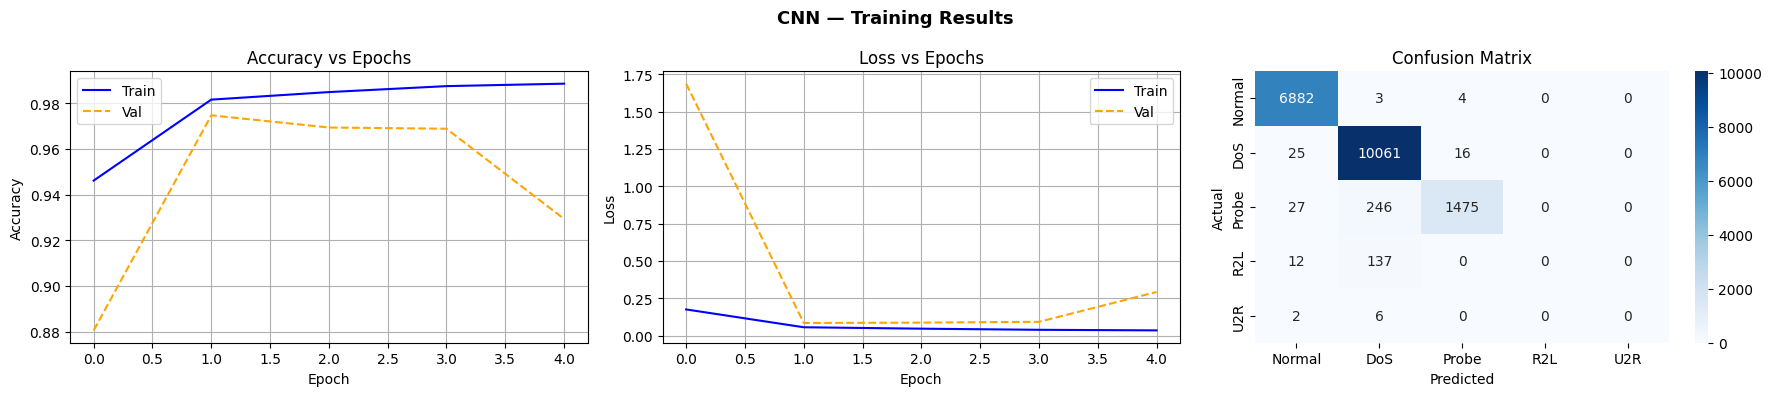

  Plot saved as results_CNN.png


In [14]:
# ── EVALUATE CNN ─────────────────────────────────────────────────────────────
evaluate_model(cnn_model, X_val_3d, y_val, y_val_cat, "CNN", cnn_history)


## 🟠 Model 2 — RNN (Recurrent Neural Network using LSTM cells)

**How RNN works for this problem:**
- Reads the 41 features **one by one**, like reading a sentence word by word
- Has a **memory** — remembers what it saw in earlier features while reading later ones
- Can link `feature[2]` with `feature[38]` if they are related
- We use **LSTM** cells (a smarter type of RNN that handles long sequences better)


In [15]:
# ── BUILD RNN (LSTM) MODEL ───────────────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="rnn_input")

# LSTM reads features as a sequence, one step at a time
# return_sequences=True  → pass output of each step to next layer
# return_sequences=False → only pass final output
x = layers.LSTM(128, return_sequences=True)(inp)
x = layers.Dropout(0.3)(x)

x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

rnn_model = Model(inputs=inp, outputs=output, name="RNN_LSTM_Model")
rnn_model.summary()


Model: "RNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_input (InputLayer)          │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 41, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 41, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,453 (470.52 KB)

 Trainable params: 120,453 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ── COMPILE RNN ──────────────────────────────────────────────────────────────
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── TRAIN RNN ────────────────────────────────────────────────────────────────
print("Training RNN model... (LSTM is slower, please wait)")

rnn_history = rnn_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ RNN training complete!")


Training RNN model... (LSTM is slower, please wait)
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 124s 289ms/step - accuracy: 0.9156 - loss: 0.2580 - val_accuracy: 0.9521 - val_loss: 0.1113
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 127s 303ms/step - accuracy: 0.9674 - loss: 0.0957 - val_accuracy: 0.9771 - val_loss: 0.0700
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 125s 298ms/step - accuracy: 0.9749 - loss: 0.0743 - val_accuracy: 0.9826 - val_loss: 0.0544
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 141s 295ms/step - accuracy: 0.9789 - loss: 0.0637 - val_accuracy: 0.9826 - val_loss: 0.0524
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 125s 297ms/step - accuracy: 0.9810 - loss: 0.0571 - val_accuracy: 0.9851 - val_loss: 0.0468
Restoring model weights from the end of the best epoch: 5.

✅ RNN training complete!



  RNN Results
  ✅ Accuracy : 98.51%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6889
         DoS       0.98      0.99      0.99     10102
       Probe       0.97      0.95      0.96      1748
         R2L       0.68      0.49      0.57       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.99     18896
   macro avg       0.73      0.69      0.70     18896
weighted avg       0.98      0.99      0.98     18896



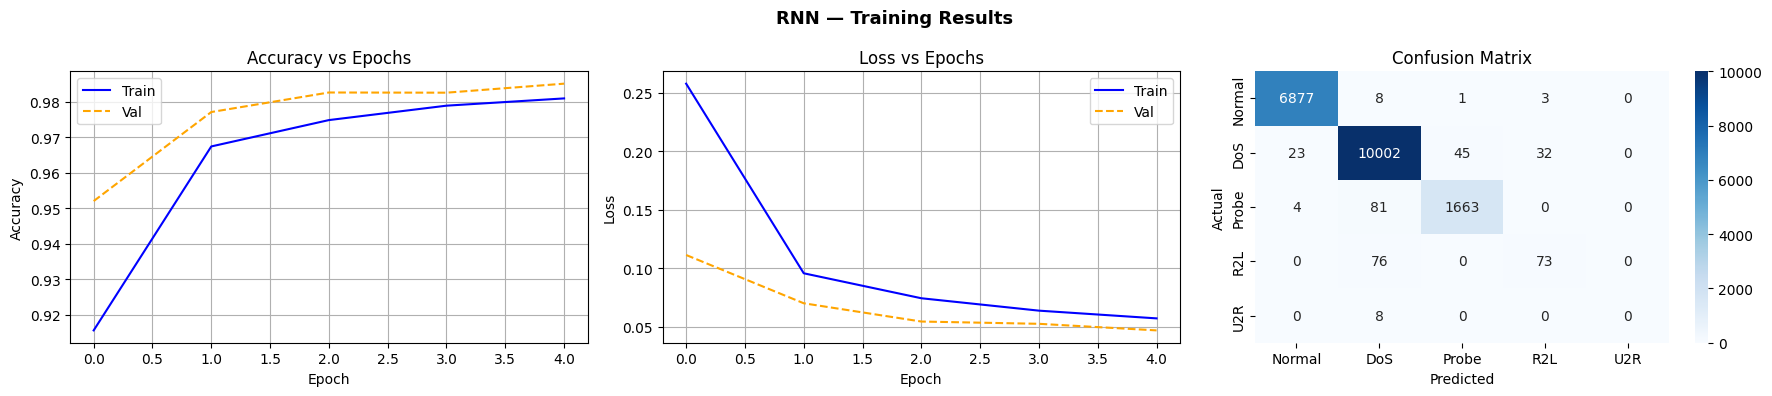

  Plot saved as results_RNN.png


In [17]:
# ── EVALUATE RNN ─────────────────────────────────────────────────────────────
evaluate_model(rnn_model, X_val_3d, y_val, y_val_cat, "RNN", rnn_history)


## 🟢 Model 3 — CNN + LSTM (Combined Model)

**How the combination works:**
- The **same input** goes into both CNN and LSTM at the same time
- CNN finds **local patterns** between nearby features
- LSTM finds **long-range relationships** across all features
- Their outputs are **joined together**
- A final Dense layer makes the prediction using both CNN and LSTM knowledge

```
Input Features
     │
  ┌──┴──┐
  ▼     ▼
 CNN   LSTM
  │     │
  └──┬──┘
     │  ← joined (Concatenate)
     ▼
 Dense Layer
     │
     ▼
Normal / DoS / Probe / R2L / U2R
```


In [18]:
# ── BUILD CNN + LSTM COMBINED MODEL ─────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="combined_input")

# ── CNN Branch : finds local feature patterns ────────────────────────────────
cnn_branch = layers.Conv1D(64,  kernel_size=3, activation="relu", padding="same")(inp)
cnn_branch = layers.BatchNormalization()(cnn_branch)
cnn_branch = layers.Conv1D(32,  kernel_size=3, activation="relu", padding="same")(cnn_branch)
cnn_branch = layers.GlobalAveragePooling1D()(cnn_branch)   # shape becomes (32,)
cnn_branch = layers.Dropout(0.3)(cnn_branch)

# ── LSTM Branch : reads features as sequence with memory ─────────────────────
lstm_branch = layers.LSTM(64, return_sequences=False)(inp)
lstm_branch = layers.Dropout(0.3)(lstm_branch)
lstm_branch = layers.Dense(32, activation="relu")(lstm_branch)  # shape becomes (32,)

# ── Join CNN + LSTM outputs ──────────────────────────────────────────────────
#   CNN output  shape : (32,)
#   LSTM output shape : (32,)
#   After joining     : (64,)  ← combined knowledge of both
combined = layers.Concatenate(name="join_cnn_lstm")([cnn_branch, lstm_branch])

combined = layers.Dense(64, activation="relu")(combined)
combined = layers.Dropout(0.2)(combined)

output = layers.Dense(NUM_CLASSES, activation="softmax")(combined)

cnn_lstm_model = Model(inputs=inp, outputs=output, name="CNN_LSTM_Model")
cnn_lstm_model.summary()


Model: "CNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ combined_input      │ (None, 41, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 41, 64)    │        256 │ combined_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 41, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 41, 32)    │      6,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     16,896 │ combined_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d_4[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ join_cnn_lstm       │ (None, 64)        │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ join_cnn_lstm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        325 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,149 (117.77 KB)

 Trainable params: 30,021 (117.27 KB)

 Non-trainable params: 128 (512.00 B)

In [19]:
# ── COMPILE CNN+LSTM ─────────────────────────────────────────────────────────
cnn_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── TRAIN CNN+LSTM ───────────────────────────────────────────────────────────
print("Training CNN+LSTM combined model...")

cnn_lstm_history = cnn_lstm_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ CNN+LSTM training complete!")


Training CNN+LSTM combined model...
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - accuracy: 0.9147 - loss: 0.2633 - val_accuracy: 0.9523 - val_loss: 0.1351
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9673 - loss: 0.1008 - val_accuracy: 0.9766 - val_loss: 0.0752
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9741 - loss: 0.0806 - val_accuracy: 0.9776 - val_loss: 0.0687
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9776 - loss: 0.0697 - val_accuracy: 0.9818 - val_loss: 0.0542
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9806 - loss: 0.0601 - val_accuracy: 0.9847 - val_loss: 0.0449
Restoring model weights from the end of the best epoch: 5.

✅ CNN+LSTM training complete!



  CNN+LSTM Results
  ✅ Accuracy : 98.47%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      6889
         DoS       0.98      0.99      0.99     10102
       Probe       0.97      0.95      0.96      1748
         R2L       0.61      0.44      0.51       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.98     18896
   macro avg       0.71      0.68      0.69     18896
weighted avg       0.98      0.98      0.98     18896



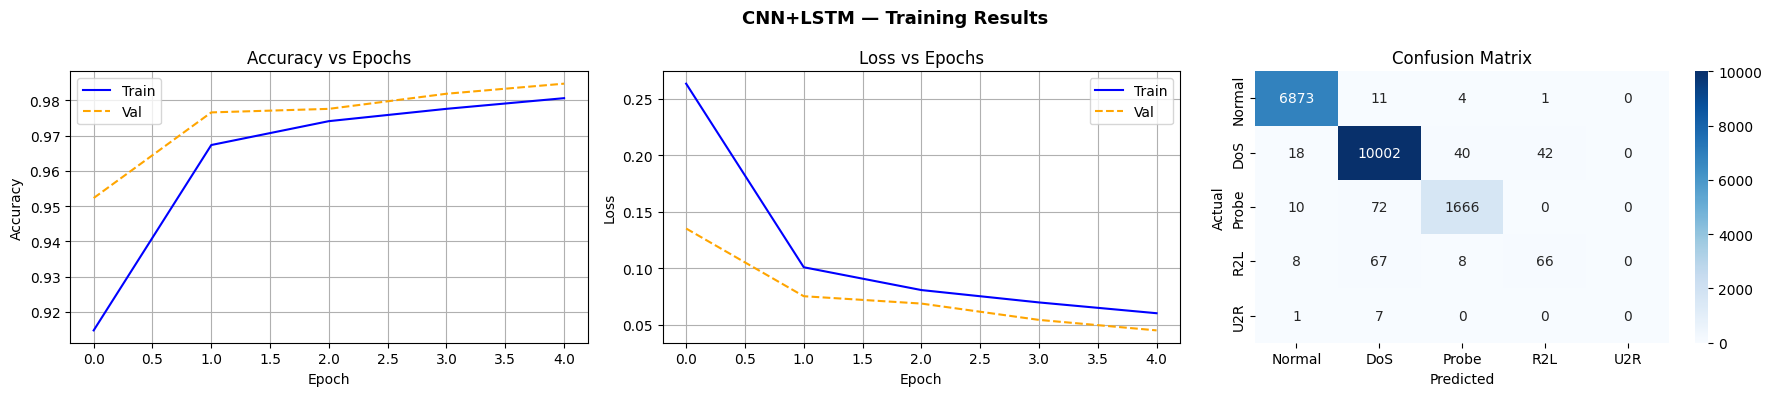

  Plot saved as results_CNN+LSTM.png


In [20]:
# ── EVALUATE CNN+LSTM ────────────────────────────────────────────────────────
evaluate_model(cnn_lstm_model, X_val_3d, y_val, y_val_cat, "CNN+LSTM", cnn_lstm_history)


In [21]:
#GRU

from tensorflow.keras import layers, Model, Input

inp = Input(shape=INPUT_SHAPE, name="gru_input")

x = layers.GRU(128, return_sequences=True)(inp)
x = layers.GRU(64)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

gru_model = Model(inputs=inp, outputs=output, name="GRU_Model")
gru_model.summary()

gru_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Training GRU model...")

gru_history = gru_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ GRU training complete!")

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_input (InputLayer)          │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 41, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,453 (408.02 KB)

 Trainable params: 104,453 (408.02 KB)

 Non-trainable params: 0 (0.00 B)

Training GRU model...
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 126s 291ms/step - accuracy: 0.9239 - loss: 0.2579 - val_accuracy: 0.9638 - val_loss: 0.1039
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 125s 298ms/step - accuracy: 0.9685 - loss: 0.0921 - val_accuracy: 0.9820 - val_loss: 0.0592
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 124s 296ms/step - accuracy: 0.9802 - loss: 0.0615 - val_accuracy: 0.9859 - val_loss: 0.0454
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 120s 287ms/step - accuracy: 0.9841 - loss: 0.0505 - val_accuracy: 0.9883 - val_loss: 0.0406
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 121s 288ms/step - accuracy: 0.9860 - loss: 0.0438 - val_accuracy: 0.9898 - val_loss: 0.0380
Restoring model weights from the end of the best epoch: 5.

✅ GRU training complete!



  GRU Results
  ✅ Accuracy : 98.98%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6889
         DoS       0.99      0.99      0.99     10102
       Probe       0.97      0.97      0.97      1748
         R2L       0.97      0.62      0.75       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.99     18896
   macro avg       0.78      0.72      0.74     18896
weighted avg       0.99      0.99      0.99     18896



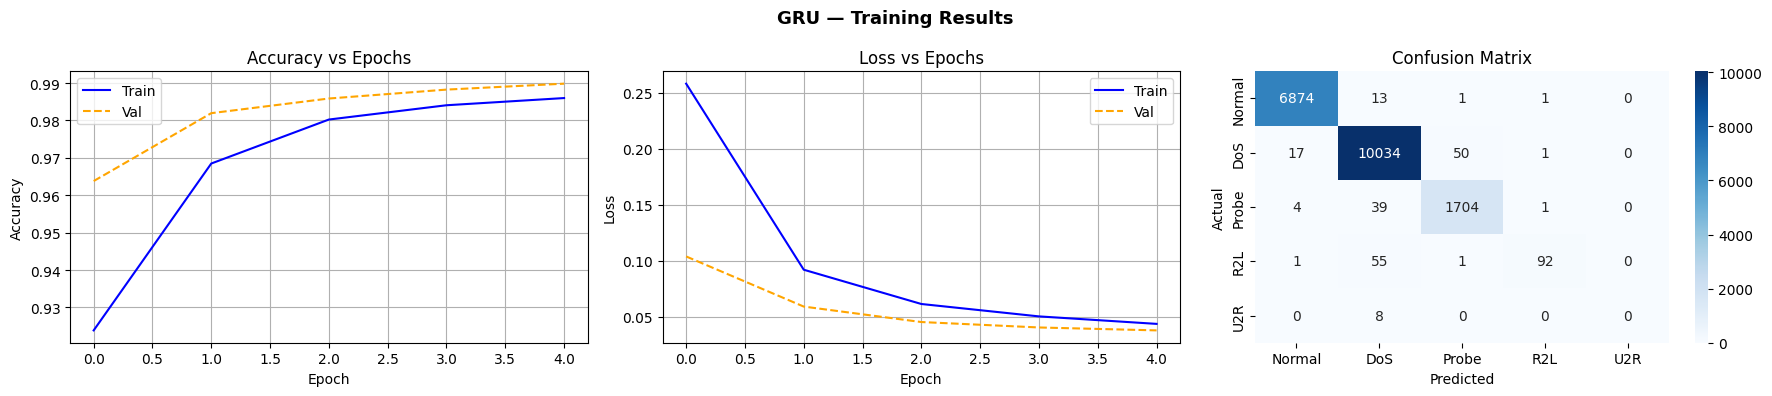

  Plot saved as results_GRU.png


In [22]:
evaluate_model(
    gru_model,
    X_val_3d,
    y_val,
    y_val_cat,
    "GRU",
    gru_history
)

In [23]:
from tensorflow.keras import layers, Model, Input

inp = Input(shape=INPUT_SHAPE, name="cnn_gru_input")

# ---- CNN Feature Extractor ----
x = layers.Conv1D(64, 3, activation="relu", padding="same")(inp)
x = layers.BatchNormalization()(x)

x = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)

# ---- GRU for temporal learning ----
x = layers.GRU(128, return_sequences=False)(x)

# ---- Dense Layers ----
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_gru_model = Model(inputs=inp, outputs=output, name="CNN_GRU_Model")
cnn_gru_model.summary()

# ---- Compile ----
cnn_gru_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ---- Train ----
print("Training CNN+GRU model...")

cnn_gru_history = cnn_gru_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ CNN+GRU training complete!")

Model: "CNN_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_gru_input (InputLayer)      │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 41, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 41, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,893 (585.52 KB)

 Trainable params: 149,509 (584.02 KB)

 Non-trainable params: 384 (1.50 KB)

Training CNN+GRU model...
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 129s 298ms/step - accuracy: 0.9442 - loss: 0.1838 - val_accuracy: 0.9471 - val_loss: 0.1669
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 124s 295ms/step - accuracy: 0.9789 - loss: 0.0637 - val_accuracy: 0.9865 - val_loss: 0.0420
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 142s 296ms/step - accuracy: 0.9859 - loss: 0.0431 - val_accuracy: 0.9898 - val_loss: 0.0336
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 143s 298ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9927 - val_loss: 0.0251
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 123s 294ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.9935 - val_loss: 0.0234
Restoring model weights from the end of the best epoch: 5.

✅ CNN+GRU training complete!


In [ ]:
evaluate_model(
    cnn_gru_model,
    X_val_3d,
    y_val,
    y_val_cat,
    "CNN+GRU",
    cnn_gru_history
)

evaluate_model(
    gru_model,
    X_val_3d,
    y_val,
    y_val_cat,
    "GRU",
    gru_history
)

## 📊 Final Comparison — All Models Side by Side

Which model performed best?


In [ ]:
print("\n" + "="*55)
print("           FINAL MODEL COMPARISON")
print("="*55)

# Sort models by accuracy (descending)
sorted_results = sorted(all_results.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6}{'Model':<20}{'Accuracy (%)':>15}")
print("-"*55)

for i, (model_name, acc) in enumerate(sorted_results, 1):
    print(f"{i:<6}{model_name:<20}{acc:>15.2f}")

print("="*55)

best_model, best_acc = sorted_results[0]
print(f"\n🏆 Best Model : {best_model} ({best_acc:.2f}%)")

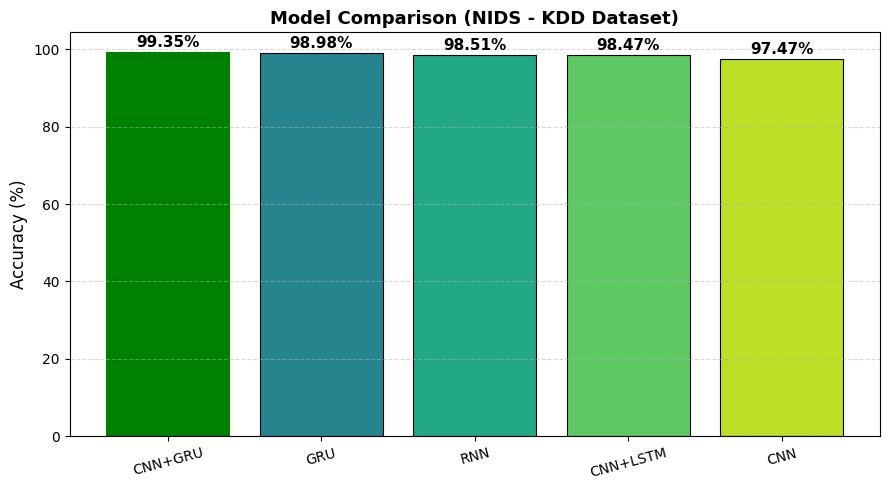

✅ Comparison chart saved as model_comparison.png


In [27]:
import matplotlib.pyplot as plt
import numpy as np

models = [x[0] for x in sorted_results]
accuracies = [x[1] for x in sorted_results]

fig, ax = plt.subplots(figsize=(9, 5))

# Generate dynamic colors
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(models)))

bars = ax.bar(models, accuracies, color=colors, edgecolor="black", linewidth=0.8)

# Highlight best model
bars[0].set_color("green")

# Add labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_ylim(0, max(accuracies) + 5)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title(
    "Model Comparison (NIDS - KDD Dataset)",
    fontsize=13,
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

print("✅ Comparison chart saved as model_comparison.png")